# Torus Benchmark

Evaluates manifold-learning methods on a flat torus embedded in $\mathbb{R}^3$, using shortest-path geodesic on the clean reference data as ground truth (DEMaP convention).

The torus has genus 1 (non-trivial topology) and zero intrinsic Gaussian curvature on average. Unlike the Swiss roll, it cannot be flattened to a plane without cutting along two non-contractible loops. This makes it a test of topology preservation, distinct from the curvature test (sphere) and the unrolling test (Swiss roll).

The embedded torus in $\mathbb{R}^3$ has no closed-form Riemannian geodesic (unlike sphere or Swiss roll), so shortest-path on the kNN graph is the natural ground-truth protocol.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

from utils.benchmark_utils import (
    METHODS, LEVEL1_METHODS,
    METRIC_INFO, DEFAULT_K_TRUST,
    level1_metrics, level2_metrics, fmt, demap,
    get_methods, METHOD_FAMILIES,
    save_synthetic_artifacts,
)
from utils.torus_utils import make_torus_with_shortest_path_geodesic
from utils.plot_config import PLOT_METHODS, PANEL_SIZE, POINT_KWARGS
from utils.helpers import extract_method_distances

import warnings
warnings.filterwarnings("ignore")


## Configuration

Torus uses only shortest-path geodesic (no closed-form analytic geodesic for the embedded torus in $\mathbb{R}^3$). `GEODESIC_TYPE` is kept as a variable for filename consistency with other dataset notebooks.

In [2]:
# Geodesic protocol (only shortest_path makes sense for embedded torus)
GEODESIC_TYPE = "shortest_path"

# Dataset parameters — standard donut (R/r = 3:1, well-separated hole)
N_SAMPLES    = 2000
NOISE        = 0.05
R_MAJOR      = 3.0
R_MINOR      = 1.0

# Experiment parameters
N_SEEDS      = 30
SEEDS        = list(range(42, 42 + N_SEEDS))
PLOT_SEED    = SEEDS[0]

# Method / metric parameters
K_TRUST      = 50
K_NN         = 15
K_GEO        = 15      # kNN graph for ground-truth geodesic
k_demap      = 30      # PHATE convention

EXPORT_LATEX = True


In [3]:
# Output paths
TAG = GEODESIC_TYPE
RESULTS_DIR = PROJECT_ROOT / "results" / "torus" / TAG
FIGURES_DIR = PROJECT_ROOT / "figures" / "torus" / TAG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geodesic protocol: {GEODESIC_TYPE}")
print(f"Torus dimensions:  R = {R_MAJOR}, r = {R_MINOR} (aspect {R_MAJOR/R_MINOR:.1f})")
print(f"Results dir:       {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:       {FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Geodesic protocol: shortest_path
Torus dimensions:  R = 3.0, r = 1.0 (aspect 3.0)
Results dir:       results/torus/shortest_path
Figures dir:       figures/torus/shortest_path


## Data generator

Returns `(X, t, D_geo, X_clean)` matching the convention used across datasets.

- `X`: noisy torus points in $\mathbb{R}^3$
- `t`: major angle $\theta \in [0, 2\pi)$, used for coloring
- `D_geo`: shortest-path geodesic on clean reference data
- `X_clean`: noise-free reference points for DEMaP

In [4]:
def make_data(seed):
    """Generate torus with shortest-path geodesic ground truth."""
    return make_torus_with_shortest_path_geodesic(
        n_samples=N_SAMPLES, R=R_MAJOR, r=R_MINOR,
        noise=NOISE, random_state=seed, k_geo=K_GEO,
    )

method_names = list(get_methods(0).keys())
print(f"Methods evaluated: {len(method_names)}")
print(method_names)
print(f"\nLevel-1 (distance-fidelity) methods: {LEVEL1_METHODS}")


Methods evaluated: 12
['PCA', 'MDS', 'UMAP', 't-SNE', 'Isomap', 'Shortest Path', 'Laplacian Eigenmaps', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

Level-1 (distance-fidelity) methods: ['Euclidean', 'Isomap', 'Shortest Path', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']


In [5]:
# Result containers
metric_names_l2 = list(METRIC_INFO.keys())
metric_names_l1 = ["spearman_row", "pearson_row",
                   "spearman_global", "pearson_global"]

results_l2 = {
    name: {m: [] for m in metric_names_l2}
    for name in method_names
}
results_l1 = {
    name: {m: [] for m in metric_names_l1}
    for name in LEVEL1_METHODS
}

embeddings_plot    = {}
dist_matrices_plot = {}


## Multi-seed experiment loop

In [6]:
for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")

    X, t, D_geo, X_clean = make_data(seed)
    methods = get_methods(seed=seed, k_nn=K_NN)

    for name, method in methods.items():
        print(f"  {name}")
        try:
            emb = method.fit_transform(X)

            # Level 2 — embedding fidelity against ground-truth geodesic
            m2 = level2_metrics(X, emb, D_geo, k=K_TRUST)
            m2["demap"] = demap(X_clean, emb, knn=k_demap)
            for metric, v in m2.items():
                results_l2[name][metric].append(v)

            # Level 1 — distance matrix fidelity (where exposed)
            D_method = extract_method_distances(method, name)
            if D_method is not None and name in LEVEL1_METHODS:
                m1 = level1_metrics(D_method, D_geo)
                for metric, v in m1.items():
                    results_l1[name][metric].append(v)
                if seed == PLOT_SEED:
                    dist_matrices_plot[name] = D_method

            if seed == PLOT_SEED:
                embeddings_plot[name] = emb

        except Exception as e:
            print(f"    FAILED: {e}")

    # Level 1 Euclidean baseline
    D_eucl = squareform(pdist(X, metric="euclidean"))
    m1 = level1_metrics(D_eucl, D_geo)
    for metric, v in m1.items():
        results_l1["Euclidean"][metric].append(v)
    if seed == PLOT_SEED:
        dist_matrices_plot["Euclidean"] = D_eucl

print("\n=== Done ===")
for name in method_names:
    n = len(results_l2[name]["spearman_row"])
    print(f"  L2 {name:<22s}: {n} seeds")
for name in LEVEL1_METHODS:
    n = len(results_l1[name]["spearman_row"])
    print(f"  L1 {name:<22s}: {n} seeds")



=== Seed 42 ===
  PCA
  MDS
  UMAP


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by 2.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 43 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by -1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 44 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by 1.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 45 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
 

## Results tables

### Level 2 — embedding evaluation

In [7]:
local_metrics  = ["trust", "continuity", "mrre_false", "mrre_missing"]
global_metrics = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global", "demap"]


def build_l2_table(metric_list):
    rows = []
    for name in METHODS:
        s = results_l2.get(name)
        if not s["spearman_row"]:
            continue
        row = {"Method": name}
        for m in metric_list:
            row[METRIC_INFO[m]] = fmt(s[m])
        rows.append(row)
    return pd.DataFrame(rows).set_index("Method")


df_local  = build_l2_table(local_metrics)
df_global = build_l2_table(global_metrics)

print(f"=== Level 2 — Local metrics ({GEODESIC_TYPE} geodesic) ===")
print(df_local.to_string())
print()
print(f"=== Level 2 — Global metrics ({GEODESIC_TYPE} geodesic) ===")
print(df_global.to_string())

if EXPORT_LATEX:
    print("\n=== LaTeX: local ===")
    print(df_local.to_latex(
        escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_local.columns),
        bold_rows=True,
    ))
    print("\n=== LaTeX: global ===")
    print(df_global.to_latex(
        escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_global.columns),
        bold_rows=True,
    ))


=== Level 2 — Local metrics (shortest_path geodesic) ===
                    Trustworthiness     Continuity MRRE false (↓) MRRE missing (↓)
Method                                                                            
PCA                   0.976 ± 0.001  0.995 ± 0.000  0.968 ± 0.001    0.994 ± 0.000
MDS                   0.976 ± 0.001  0.994 ± 0.000  0.969 ± 0.001    0.994 ± 0.000
UMAP                  0.993 ± 0.001  0.979 ± 0.001  0.995 ± 0.001    0.988 ± 0.001
t-SNE                 0.995 ± 0.001  0.980 ± 0.001  0.997 ± 0.000    0.988 ± 0.000
Isomap                0.975 ± 0.001  0.992 ± 0.000  0.968 ± 0.001    0.993 ± 0.000
Shortest Path         0.976 ± 0.001  0.994 ± 0.000  0.969 ± 0.001    0.994 ± 0.000
Laplacian Eigenmaps   0.959 ± 0.002  0.977 ± 0.000  0.963 ± 0.001    0.983 ± 0.000
Diffusion Maps        0.959 ± 0.002  0.977 ± 0.000  0.962 ± 0.001    0.983 ± 0.000
PHATE                 0.955 ± 0.001  0.976 ± 0.000  0.958 ± 0.001    0.981 ± 0.000
HeatGeo               0.975 ± 

### Level 1 — distance matrix evaluation

In [8]:
level1_display = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global"]
level1_labels = {
    "spearman_row":    "Spearman (row)",
    "pearson_row":     "Pearson (row)",
    "spearman_global": "Spearman (global)",
    "pearson_global":  "Pearson (global)",
}

rows = []
for name in LEVEL1_METHODS:
    s = results_l1[name]
    if not s["spearman_row"]:
        continue
    row = {"Method": name}
    for m in level1_display:
        row[level1_labels[m]] = fmt(s[m])
    rows.append(row)

df_l1 = pd.DataFrame(rows).set_index("Method")
print(f"=== Level 1 — Distance matrix evaluation ({GEODESIC_TYPE} geodesic) ===")
print(df_l1.to_string())
print()
print(df_l1.to_latex(escape=False, float_format="%.3f",
                     column_format="l" + "c" * len(df_l1.columns)))


=== Level 1 — Distance matrix evaluation (shortest_path geodesic) ===
               Spearman (row)  Pearson (row) Spearman (global) Pearson (global)
Method                                                                         
Euclidean       0.983 ± 0.000  0.982 ± 0.000     0.982 ± 0.000    0.982 ± 0.000
Isomap          0.999 ± 0.000  0.999 ± 0.000     0.999 ± 0.000    0.999 ± 0.000
Shortest Path   0.999 ± 0.000  0.999 ± 0.000     0.999 ± 0.000    0.999 ± 0.000
Diffusion Maps  0.464 ± 0.014  0.522 ± 0.006     0.431 ± 0.019    0.503 ± 0.010
PHATE           0.960 ± 0.001  0.939 ± 0.002     0.944 ± 0.002    0.920 ± 0.002
HeatGeo         0.987 ± 0.002  0.984 ± 0.002     0.980 ± 0.003    0.975 ± 0.003
DTNE            0.984 ± 0.001  0.971 ± 0.002     0.975 ± 0.002    0.958 ± 0.003
EntroPath       0.976 ± 0.006  0.968 ± 0.006     0.964 ± 0.009    0.958 ± 0.008

\begin{tabular}{lcccc}
\toprule
 & Spearman (row) & Pearson (row) & Spearman (global) & Pearson (global) \\
Method &  &  &  &  \\

### Correlation gap (Level 1 → Level 2)

In [9]:
print(f"=== Correlation gap ({GEODESIC_TYPE} geodesic) ===")
print(f"{'Method':<18} {'L1 Spearman':>14} {'L2 Spearman':>14} {'Gap':>8}")
print("-" * 58)
for name in LEVEL1_METHODS:
    if name == "Euclidean" or name not in results_l2:
        continue
    if not results_l1[name]["spearman_row"]:
        continue
    if not results_l2[name]["spearman_row"]:
        continue
    l1  = np.mean(results_l1[name]["spearman_row"])
    l2  = np.mean(results_l2[name]["spearman_row"])
    gap = l1 - l2
    print(f"{name:<18} {l1:>14.3f} {l2:>14.3f} {gap:>8.3f}")


=== Correlation gap (shortest_path geodesic) ===
Method                L1 Spearman    L2 Spearman      Gap
----------------------------------------------------------
Isomap                      0.999          0.980    0.019
Shortest Path               0.999          0.979    0.020
Diffusion Maps              0.464          0.963   -0.499
PHATE                       0.960          0.961   -0.001
HeatGeo                     0.987          0.976    0.011
DTNE                        0.984          0.972    0.011
EntroPath                   0.976          0.974    0.002


## Save results

In [10]:
import json


def _serialise(store):
    out = {}
    for name, metrics in store.items():
        if not any(metrics.values()):
            continue
        out[name] = {
            m: {"mean": float(np.mean(v)),
                "std":  float(np.std(v)),
                "n":    len(v)}
            for m, v in metrics.items() if v
        }
    return out


l2_path = RESULTS_DIR / f"torus_{TAG}_level2.json"
l1_path = RESULTS_DIR / f"torus_{TAG}_level1.json"

with open(l2_path, "w") as f:
    json.dump(_serialise(results_l2), f, indent=2)
with open(l1_path, "w") as f:
    json.dump(_serialise(results_l1), f, indent=2)

print(f"Level 2 saved to {l2_path.relative_to(PROJECT_ROOT)}")
print(f"Level 1 saved to {l1_path.relative_to(PROJECT_ROOT)}")


Level 2 saved to results/torus/shortest_path/torus_shortest_path_level2.json
Level 1 saved to results/torus/shortest_path/torus_shortest_path_level1.json


## Plots

### Embedding row (input + selected methods)

Color encodes the major angle $\theta$. We use the cyclic colormap `twilight` to avoid a visible discontinuity at the $\theta = 0 / 2\pi$ seam (the major angle is periodic).

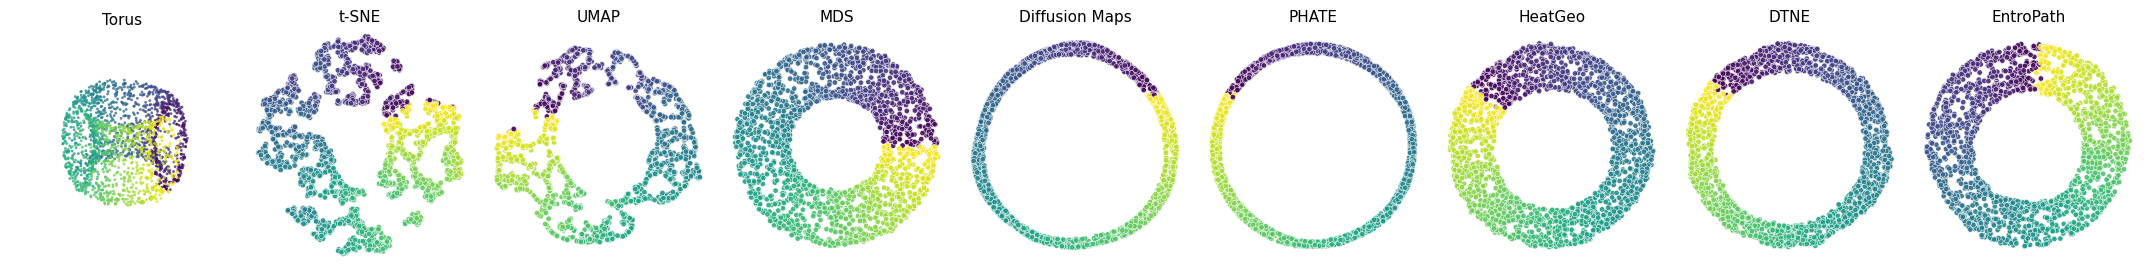

In [11]:
X_plot, t_plot, D_geo_plot, X_clean_plot = make_data(PLOT_SEED)

# Cyclic colormap for periodic theta — no discontinuity at θ = 0/2π
CMAP = "viridis"
norm = plt.Normalize(0, 2*np.pi)

n_panels = 1 + len(PLOT_METHODS)
PANEL = 2.4
fig, axes = plt.subplots(1, n_panels,
                         figsize=(PANEL * n_panels, PANEL + 0.4))

POINT_KWARGS = dict(s=15, alpha=0.9, linewidths=0.4,
                    edgecolors="white", rasterized=True)

# 3D input panel
axes[0].remove()
ax3d = fig.add_subplot(1, n_panels, 1, projection="3d")
ax3d.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2],
             c=t_plot, cmap=CMAP, norm=norm,
             s=4, alpha=0.8, linewidths=0, rasterized=True)
ax3d.set_title("Torus", fontsize=11, pad=6)
ax3d.set_axis_off()
ax3d.view_init(elev=30, azim=-60)

# 2D method panels
for idx, name in enumerate(PLOT_METHODS, start=1):
    ax = axes[idx]
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        ax.scatter(emb[:, 0], emb[:, 1],
                   c=t_plot, cmap=CMAP, norm=norm,
                   **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_{TAG}_row.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"torus_{TAG}_row.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Standalone 3D torus

Saved separately for use in side-by-side figures in the paper.

In [12]:
fig = plt.figure(figsize=(3.5, 3.5))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2],
             c=t_plot, cmap=CMAP, norm=norm,
             s=4, alpha=0.8, linewidths=0, rasterized=False)
ax3d.set_axis_off()
ax3d.view_init(elev=30, azim=-60)
# Keep proportional aspect ratio for the donut shape
ax3d.set_box_aspect([1, 1, R_MINOR / R_MAJOR])

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_3d_{TAG}.pdf",
            bbox_inches="tight", pad_inches=0.1)
plt.savefig(FIGURES_DIR / f"torus_3d_{TAG}.png",
            dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.close()
print("Saved standalone 3D torus.")


Saved standalone 3D torus.


### Embedding grid (all methods)

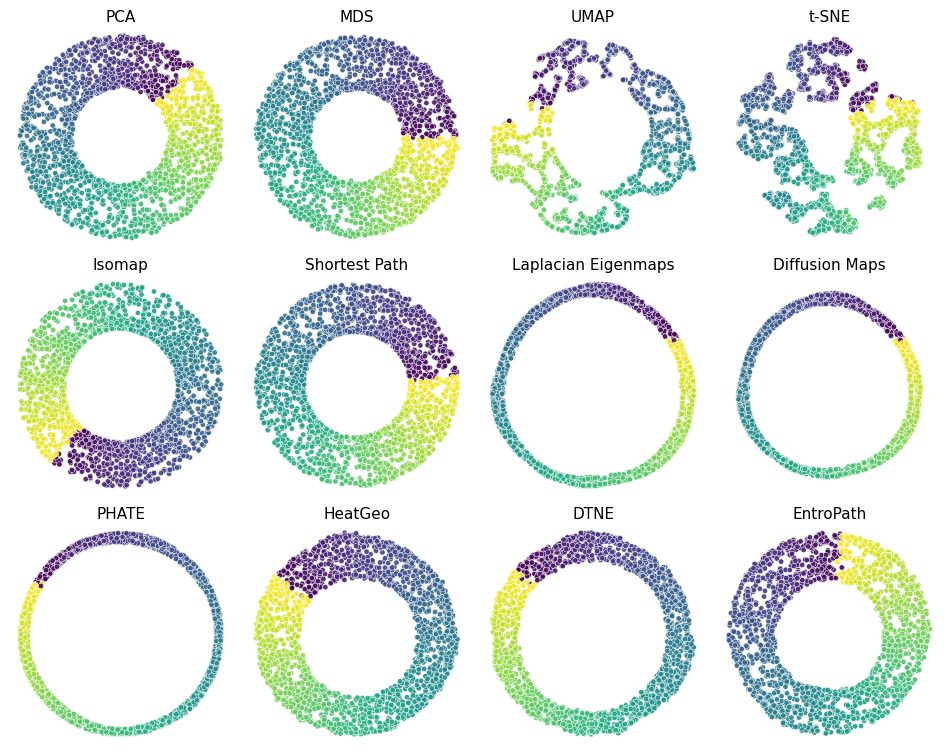

In [13]:
n_cols = 4
n_rows = -(-len(METHODS) // n_cols)

PANEL = 2.4
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(PANEL * n_cols, PANEL * n_rows + 0.4))
axes = axes.flatten()

for ax, name in zip(axes, METHODS):
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        ax.scatter(emb[:, 0], emb[:, 1],
                   c=t_plot, cmap=CMAP, norm=norm,
                   **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

for ax in axes[len(METHODS):]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig(FIGURES_DIR / f"embeddings_grid_torus_{TAG}.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"embeddings_grid_torus_{TAG}.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Save artifacts

In [14]:
save_synthetic_artifacts(
    embeddings_plot, {}, X_clean_plot, X_plot, t_plot,
    D_geo_plot, level2_results=None,
    config={"plot_seed": PLOT_SEED, "tag": TAG, "n_samples": N_SAMPLES,
            "noise": NOISE, "geodesic_type": GEODESIC_TYPE},
    results_dir=RESULTS_DIR, basename=f"swiss_roll_{TAG}",
)

PosixPath('/Users/przemyslawrola/Desktop/EntroPath/results/torus/shortest_path/swiss_roll_shortest_path_artifacts.pkl')

### Shepard diagram

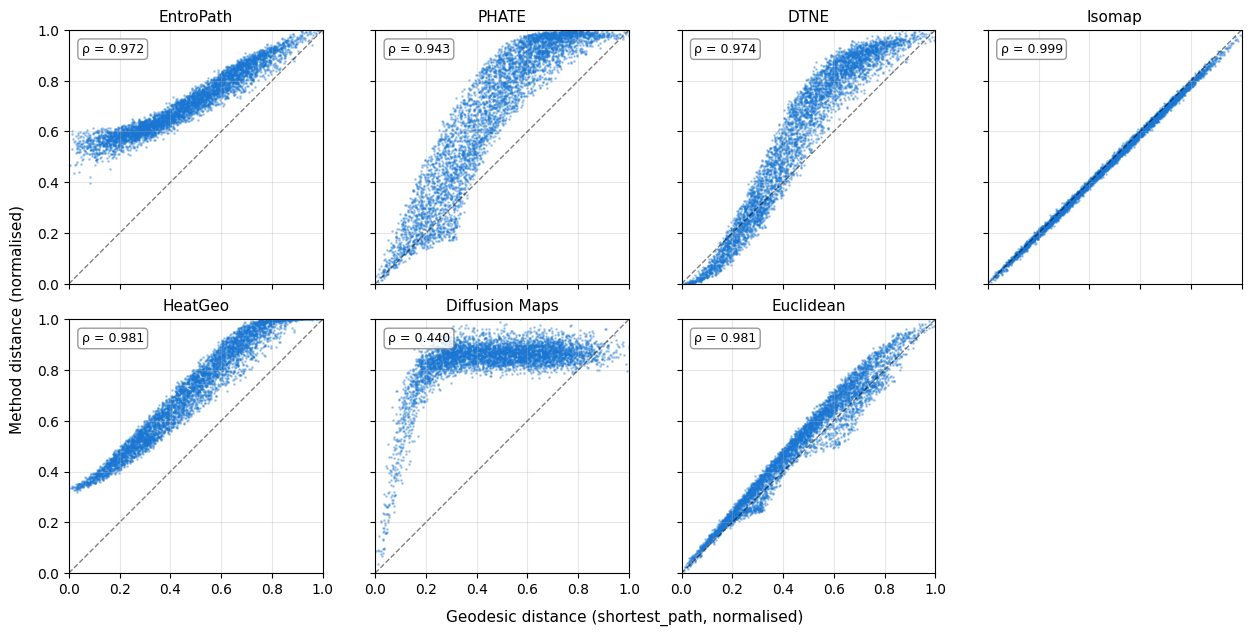

In [15]:
PLOT_DIST_METHODS = ["EntroPath", "PHATE", "DTNE", "Isomap",
                     "HeatGeo", "Diffusion Maps", "Euclidean"]

n     = D_geo_plot.shape[0]
upper = np.triu_indices(n, k=1)
rng   = np.random.default_rng(42)
idx   = rng.choice(len(upper[0]), size=min(5000, len(upper[0])), replace=False)
rows_, cols_ = upper[0][idx], upper[1][idx]
geo_vals = D_geo_plot[rows_, cols_]
geo_norm = geo_vals / geo_vals.max()

methods_to_plot = [m for m in PLOT_DIST_METHODS if m in dist_matrices_plot]
n_methods = len(methods_to_plot)
ncols = 4
nrows = -(-n_methods // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(3.2 * ncols, 3.2 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, name in zip(axes, methods_to_plot):
    D_method    = dist_matrices_plot[name]
    method_vals = D_method[rows_, cols_]
    method_norm = method_vals / method_vals.max()

    ax.scatter(geo_norm, method_norm,
               s=1, alpha=0.3, rasterized=True, color="#1976D2")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)

    rho, _ = spearmanr(geo_vals, method_vals)
    ax.text(0.05, 0.95, f"ρ = {rho:.3f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white",
                      alpha=0.8, edgecolor="gray"))

    ax.set_title(name, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

for ax in axes[n_methods:]:
    ax.set_visible(False)

fig.supxlabel(f"Geodesic distance ({GEODESIC_TYPE}, normalised)",
              fontsize=11, y=0.02)
fig.supylabel("Method distance (normalised)", fontsize=11, x=0.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_{TAG}_shepard.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"torus_{TAG}_shepard.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Box plots — Level 2 (embedding evaluation)

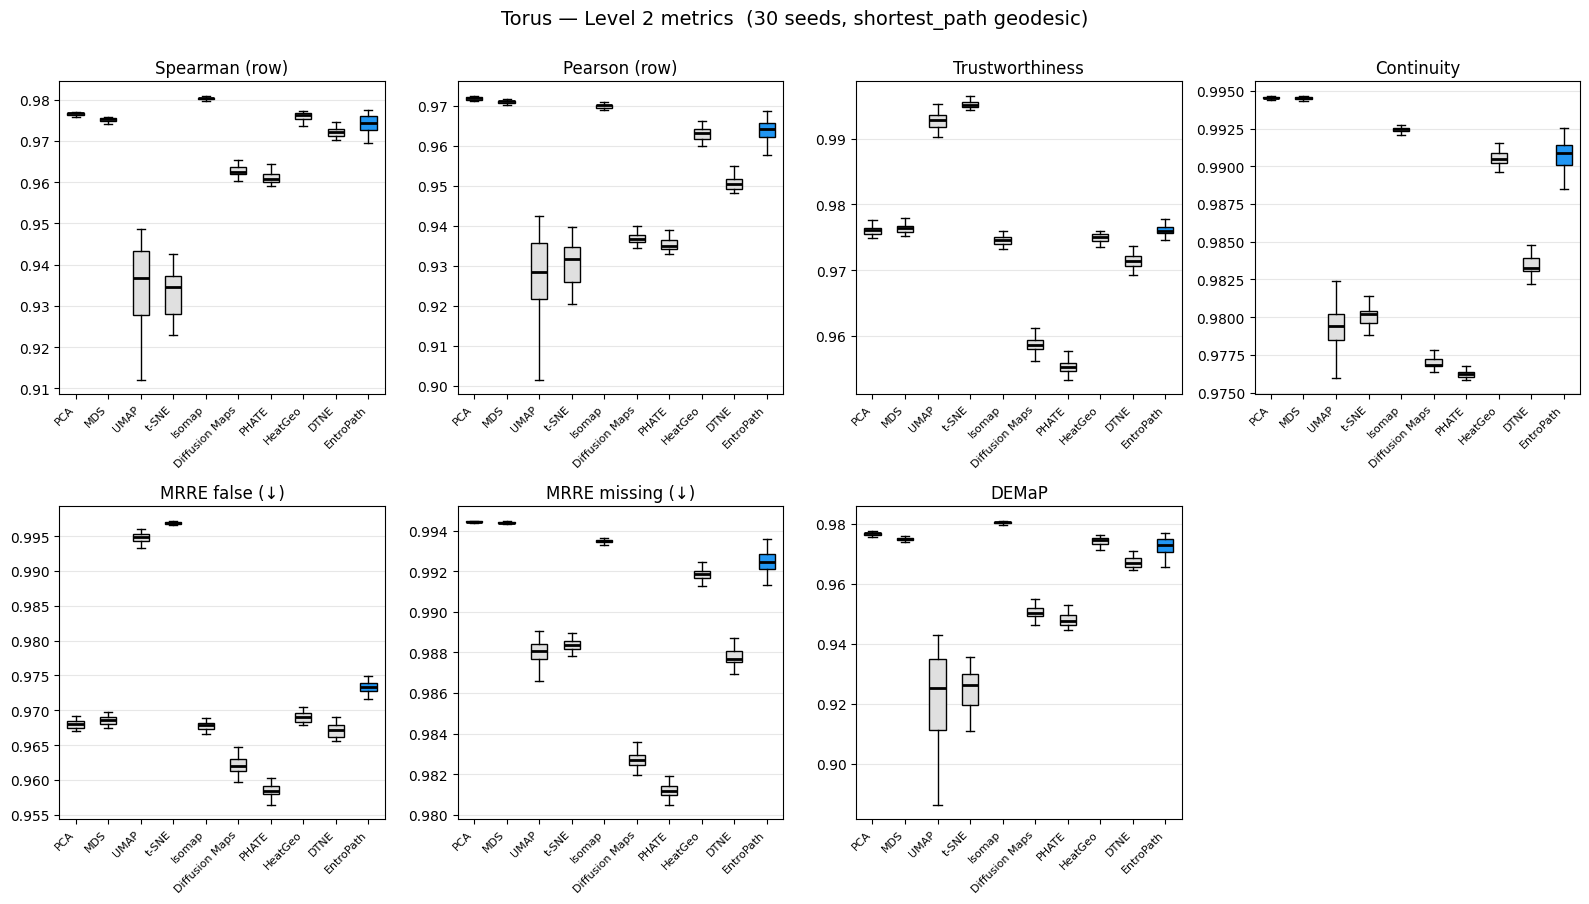

In [16]:
main_metrics = ["spearman_row", "pearson_row", "trust", "continuity",
                "mrre_false", "mrre_missing", "demap"]

BOXPLOT_METHODS = [
    "PCA", "MDS", "UMAP", "t-SNE",
    "Isomap", "Diffusion Maps",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]
plot_names = [n for n in BOXPLOT_METHODS
              if n in results_l2 and results_l2[n].get("spearman_row")]

ncols = 4
nrows = -(-len(main_metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, main_metrics):
    data = [results_l2[n][metric] for n in plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

for ax in axes[len(main_metrics):]:
    ax.set_visible(False)

plt.suptitle(
    f"Torus — Level 2 metrics  ({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.00,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_{TAG}_boxplots_l2.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"torus_{TAG}_boxplots_l2.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [17]:
summary = pd.DataFrame({
    METRIC_INFO[m]: {n: np.median(results_l2[n][m])
                     for n in BOXPLOT_METHODS
                     if n in results_l2 and results_l2[n].get(m)}
    for m in main_metrics
})
print(f"=== Median summary ({GEODESIC_TYPE} geodesic) ===")
print(summary.round(3))


=== Median summary (shortest_path geodesic) ===
                Spearman (row)  Pearson (row)  Trustworthiness  Continuity  \
PCA                      0.977          0.972            0.976       0.995   
MDS                      0.975          0.971            0.976       0.994   
UMAP                     0.937          0.929            0.993       0.979   
t-SNE                    0.935          0.932            0.995       0.980   
Isomap                   0.980          0.970            0.975       0.992   
Diffusion Maps           0.963          0.937            0.959       0.977   
PHATE                    0.961          0.935            0.955       0.976   
HeatGeo                  0.976          0.963            0.975       0.990   
DTNE                     0.972          0.950            0.971       0.983   
EntroPath                0.974          0.964            0.976       0.991   

                MRRE false (↓)  MRRE missing (↓)  DEMaP  
PCA                      0.968     

### Box plots — Level 1 (distance matrix evaluation)

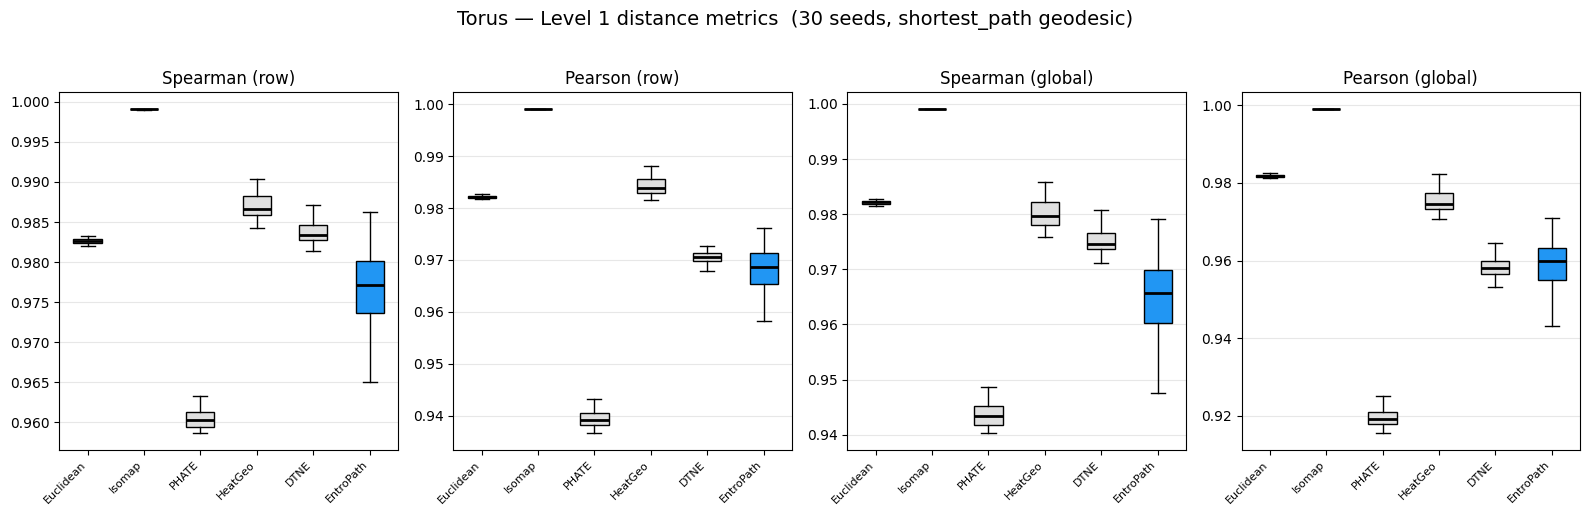

In [18]:
l1_metrics = ["spearman_row", "pearson_row",
              "spearman_global", "pearson_global"]

BOXPLOT_METHODS_L1 = [
    "Euclidean", "Isomap",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]   # Diffusion Maps tends to have degenerate Level 1 distances; excluded
l1_plot_names = [n for n in BOXPLOT_METHODS_L1
                 if n in results_l1 and results_l1[n].get("spearman_row")]

fig, axes = plt.subplots(1, len(l1_metrics),
                         figsize=(4 * len(l1_metrics), 5))

for ax, metric in zip(axes, l1_metrics):
    data = [results_l1[n][metric] for n in l1_plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in l1_plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(l1_plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(
    f"Torus — Level 1 distance metrics  "
    f"({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_{TAG}_boxplots_l1.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"torus_{TAG}_boxplots_l1.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Stability across seeds (geodesic-family methods)

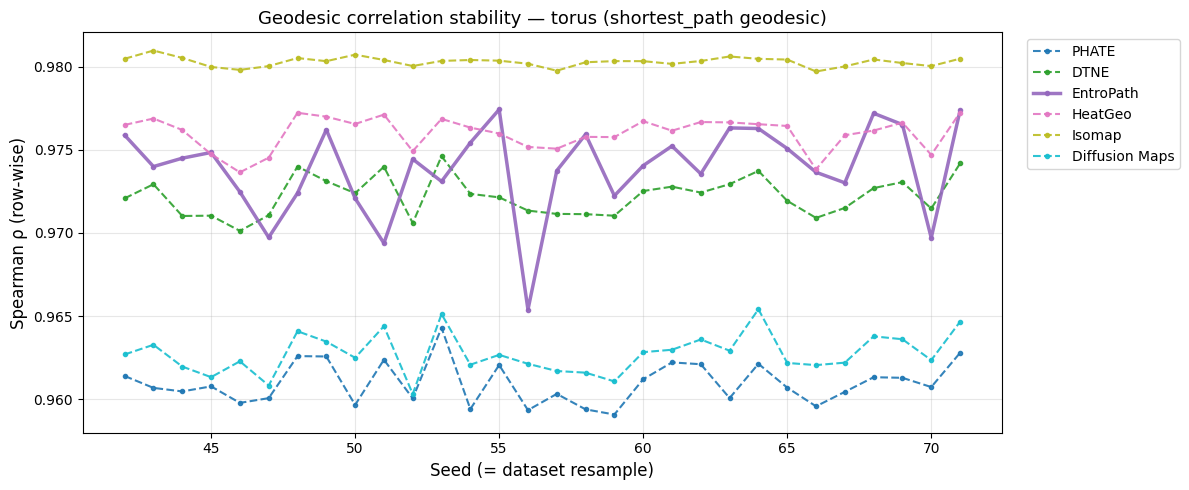

In [19]:
stability_methods = ["PHATE", "DTNE", "EntroPath", "HeatGeo",
                     "Isomap", "Diffusion Maps"]
plot_methods_names = [n for n in stability_methods
                      if n in results_l2 and results_l2[n].get("spearman_row")]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_methods_names)))

for name, color in zip(plot_methods_names, colors):
    vals = results_l2[name]["spearman_row"]
    ls   = "-" if name == "EntroPath" else "--"
    lw   = 2.5 if name == "EntroPath" else 1.5
    ax.plot(
        SEEDS[:len(vals)], vals,
        marker="o", markersize=3,
        color=color, label=name,
        linewidth=lw, linestyle=ls, alpha=0.9,
    )

ax.set_xlabel("Seed (= dataset resample)", fontsize=12)
ax.set_ylabel("Spearman ρ (row-wise)", fontsize=12)
ax.set_title(
    f"Geodesic correlation stability — torus ({GEODESIC_TYPE} geodesic)",
    fontsize=13,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"torus_{TAG}_stability.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"torus_{TAG}_stability.png",
            dpi=300, bbox_inches="tight")
plt.show()
